In [17]:
import os
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse

In [18]:
START_URL = "https://www.dawn.com"
MAX_ARTICLES = 10        # ✅ Change to 10 if your teacher requires only 10
DELAY = 1.0                # polite delay
OUTPUT_DIR = "dawn_pages"


In [19]:
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [20]:
visited = set()
queue = [START_URL]
data = []

In [21]:
headers = {
    "User-Agent": "Dawn-News-Crawler-For-Academic-Use"
}

In [22]:
def is_valid_article(url):
    parsed = urlparse(url)

    if parsed.scheme not in ("http", "https"):
        return False

    if "dawn.com" not in parsed.netloc:
        return False

    if any(url.lower().endswith(ext) for ext in [
        ".jpg", ".png", ".pdf", ".mp4", ".mp3", ".zip"
    ]):
        return False

    return True

In [23]:
def extract_article_text(html):
    soup = BeautifulSoup(html, "html.parser")

    title = soup.find("h1")
    title = title.get_text(strip=True) if title else "No Title"

    body_div = soup.find("div", class_="story__content")
    if not body_div:
        return title, ""

    paragraphs = body_div.find_all("p")
    text = "\n".join(p.get_text(strip=True) for p in paragraphs)

    return title, text


In [24]:
count = 0

while queue and count < MAX_ARTICLES:
    url = queue.pop(0)

    if url in visited:
        continue

    if not is_valid_article(url):
        continue

    print(f"[{count+1}] Crawling: {url}")

    try:
        r = requests.get(url, headers=headers, timeout=15)
        r.raise_for_status()
    except:
        continue

    visited.add(url)

    filename = f"dawn_{count+1:03d}.html"
    filepath = os.path.join(OUTPUT_DIR, filename)

    with open(filepath, "w", encoding="utf-8") as f:
        f.write(r.text)

    title, article_text = extract_article_text(r.text)

    if len(article_text) > 200:
        data.append({
            "url": url,
            "title": title,
            "content": article_text
        })
        count += 1

    soup = BeautifulSoup(r.text, "html.parser")
    for a in soup.find_all("a", href=True):
        full_url = urljoin(url, a["href"])
        full_url = full_url.split("#")[0]

        if full_url not in visited and is_valid_article(full_url):
            queue.append(full_url)

    time.sleep(DELAY)

df = pd.DataFrame(data)
df.to_csv("dawn_dataset.csv", index=False)

print(f"\n✅ DONE — Collected {count} articles")
print("✅ Dataset saved as: dawn_dataset.csv")
print("✅ Raw HTML saved in folder:", OUTPUT_DIR)


[1] Crawling: https://www.dawn.com
[1] Crawling: https://epaper.dawn.com
[1] Crawling: https://images.dawn.com
[1] Crawling: https://herald.dawn.com
[1] Crawling: https://aurora.dawn.com
[1] Crawling: https://www.dawn.com/advertise
[1] Crawling: https://www.dawn.com/events
[1] Crawling: https://www.dawn.com/events/supplements
[1] Crawling: https://www.dawn.com/jobs
[1] Crawling: https://obituary.dawn.com
[1] Crawling: https://www.dawn.com/
[1] Crawling: https://epaper.dawn.com
[1] Crawling: https://www.dawn.com/latest-news
[1] Crawling: https://www.dawn.com/pakistan
[1] Crawling: https://www.dawn.com/opinion
[1] Crawling: https://www.dawn.com/business
[1] Crawling: https://images.dawn.com
[1] Crawling: https://www.dawn.com/prism
[1] Crawling: https://www.dawn.com/world
[1] Crawling: https://www.dawn.com/sport
[1] Crawling: https://www.dawn.com/breathepakistan
[1] Crawling: https://www.dawn.com/magazines
[1] Crawling: https://www.dawn.com/tech
[1] Crawling: https://www.dawn.com/videos
[

In [1]:
!pip install nltk pandas


  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.0 MB/s  0:00:01m 1.0 MB/s eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.7/791.7 kB 1.1 MB/s  0:00:001.2 MB/s eta 0:00:01
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [nltk]━━━━━━ 4/5 [nltk]]]


In [2]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /home/usman/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /home/usman/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
import pandas as pd

df = pd.read_csv("dawn_dataset.csv")

print(df.head())
print("\nNumber of articles:", len(df))


                                                 url            title  \
0              https://aurora.dawn.com/news/1145612/  Aurora Magazine   
1              https://aurora.dawn.com/news/1145541/  Aurora Magazine   
2              https://aurora.dawn.com/news/1145591/  Aurora Magazine   
3  https://aurora.dawn.com/news/1145592/just-sayi...  Aurora Magazine   
4  https://aurora.dawn.com/news/1145566/aurora-ne...  Aurora Magazine   

                                             content  
0  EDITORIAL\nMamun M. Adil\nUzma Khateeb-NawazSh...  
1  The first edition ofAurorawas published in Jul...  
2  There is something quite\nunique in the tellin...  
3  \nPakistani consumers are enthusiastic, but no...  
4  Even thoughAurora’sscope\nwas marketing, adver...  

Number of articles: 10


In [5]:
import re

def normalize_text(text):
    text = text.lower()                      # lowercase
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = re.sub(r'[^\w\s]', '', text)      # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

df["normalized_text"] = df["content"].apply(normalize_text)


In [6]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words]
    return " ".join(filtered)

df["no_stopwords"] = df["normalized_text"].apply(remove_stopwords)


In [7]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["no_stopwords"].apply(word_tokenize)


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/home/usman/nltk_data'
    - '/home/usman/Documents/Robotics_AI/Some_projects/reinforcement_learning/genAI/.venv/nltk_data'
    - '/home/usman/Documents/Robotics_AI/Some_projects/reinforcement_learning/genAI/.venv/share/nltk_data'
    - '/home/usman/Documents/Robotics_AI/Some_projects/reinforcement_learning/genAI/.venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [8]:
df.to_csv("dawn_prepared_text.csv", index=False)

print("✅ Data preparation complete")
print("✅ Saved as dawn_prepared_text.csv")


✅ Data preparation complete
✅ Saved as dawn_prepared_text.csv


In [9]:
!pip install gensim matplotlib scikit-learn


  Using cached scikit_learn-1.7.2-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (6.3 kB)
  Using cached pillow-12.0.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached wrapt-2.0.1-cp310-cp310-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (9.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.6/27.6 MB 2.1 MB/s  0:00:13 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7

In [10]:
import pandas as pd
from gensim.models import Word2Vec

# Load prepared data
df = pd.read_csv("dawn_prepared_text.csv")

# Convert token strings back to lists
sentences = df["tokens"].apply(eval).tolist()

# Train Word2Vec model
model = Word2Vec(
    sentences=sentences,
    vector_size=100,    # embedding dimension
    window=5,           # context window
    min_count=5,        # ignore rare words
    sg=1,               # 1 = Skip-Gram
    workers=4,
    epochs=20
)

# Save model
model.save("word2vec_dawn.model")

print("✅ Word2Vec model trained and saved")


KeyError: 'tokens'

In [11]:
import pandas as pd

df = pd.read_csv("dawn_prepared_text.csv")
print(df.columns)


Index(['url', 'title', 'content', 'normalized_text', 'no_stopwords'], dtype='object')


In [14]:
from nltk.tokenize import word_tokenize
import pandas as pd

df = pd.read_csv("dawn_prepared_text.csv")

df["tokens"] = df["no_stopwords"].apply(word_tokenize)

# Save updated file
df.to_csv("dawn_prepared_text.csv", index=False)

print("✅ Tokens column created and saved")


✅ Tokens column created and saved


In [13]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to /home/usman/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/usman/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [15]:
import pandas as pd

df = pd.read_csv("dawn_prepared_text.csv")

df["tokens"] = df["no_stopwords"].apply(lambda x: x.split())

df.to_csv("dawn_prepared_text.csv", index=False)

print("✅ Tokens created using simple split()")


✅ Tokens created using simple split()


In [16]:
print(df["tokens"].iloc[0])


['editorial', 'mamun', 'adil', 'uzma', 'khateebnawazshizra', 'mangnejo', 'alphabetical', 'orderreema', 'abbasiamber', 'arshadsarwat', 'yasmeen', 'azeemleila', 'barryzeenat', 'chaudharyvanessa', 'dsouzajahanzaib', 'haquemahnaz', 'hasantabinda', 'hussainsophia', 'khantariq', 'sayeed', 'khantariq', 'ziad', 'khanfouzia', 'maparamarylou', 'mccormackareeba', 'mohsinfaisal', 'roshanosama', 'saeedosman', 'samiuddinayesha', 'shaikhalifya', 'sohailanusha', 'zahid', 'designessa', 'malik', 'radia', 'durrani', 'sarah', 'durrani', 'farooq', 'saati', 'saad', 'arifi', 'special', 'mentiontannaz', 'minwalla', 'mannan', 'hatim', 'ali', 'creative', 'unit', 'photographystephan', 'andrew', 'whitestar', 'productionkhalil', 'mohsin', 'marketingshakeel', 'masud', 'hussain', 'junaid', 'akram', 'circulationghazanfar', 'raza', 'ramzan', 'ali', 'fida', 'misimran', 'saeed', 'liaquat', 'ali', 'andmasood', 'hamid', 'niloufer', 'patelyou', 'longer', 'among', 'us', 'contribution', 'making', 'ofaurorawas', 'immense', 'c

In [17]:
from gensim.models import Word2Vec
import pandas as pd

df = pd.read_csv("dawn_prepared_text.csv")

sentences = df["tokens"].apply(eval).tolist()

model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    epochs=20,
    workers=4
)

model.save("word2vec_dawn.model")
print("✅ Word2Vec trained successfully")


✅ Word2Vec trained successfully


In [18]:
print("Vocabulary size:", len(model.wv))


Vocabulary size: 117


In [19]:
print(model.wv['pakistan'].shape)




(100,)


In [20]:
model.wv.most_similar("pakistan", topn=5)


[('years', 0.9979248642921448),
 ('become', 0.9978887438774109),
 ('last', 0.9978670477867126),
 ('pakistani', 0.9978142976760864),
 ('part', 0.997782826423645)]

In [23]:
# model.wv.most_similar("economy")
model.wv.most_similar("government")
# model.wv.most_similar("inflation")



[('last', 0.9982037544250488),
 ('policy', 0.998149573802948),
 ('two', 0.9976821541786194),
 ('come', 0.9975330829620361),
 ('also', 0.9975264072418213),
 ('like', 0.9975108504295349),
 ('made', 0.997462272644043),
 ('terms', 0.9974484443664551),
 ('ceo', 0.9973869323730469),
 ('one', 0.997377336025238)]

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.decomposition import PCA


In [25]:
model = Word2Vec.load("word2vec_dawn.model")


In [26]:
words = model.wv.index_to_key[:40]   # top 40 frequent words
vectors = np.array([model.wv[w] for w in words])


In [27]:
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)


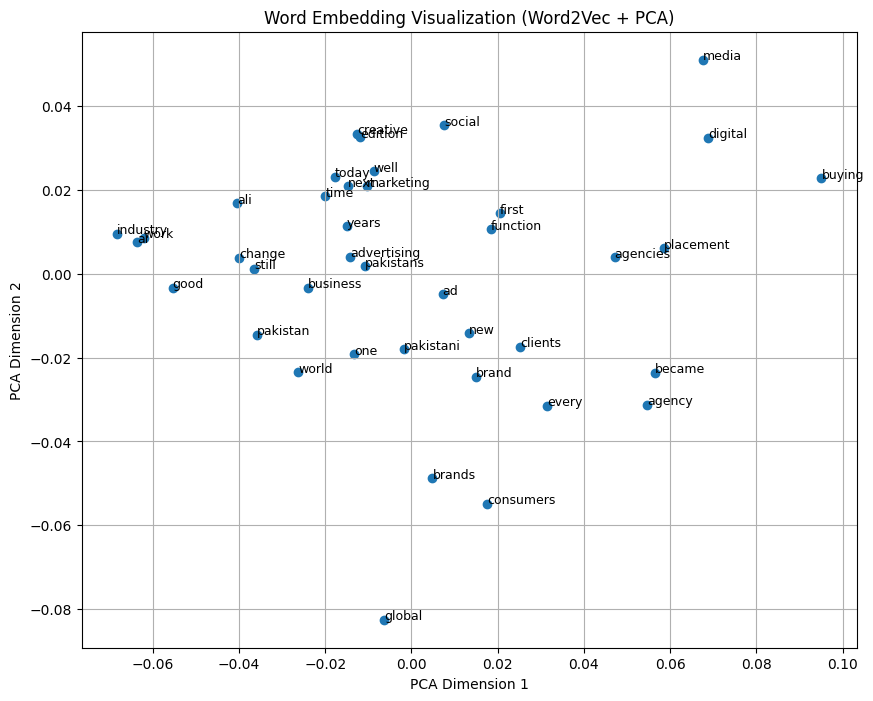

In [29]:
plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1])

for i, word in enumerate(words):
    plt.text(vectors_2d[i, 0], vectors_2d[i, 1], word, fontsize=9)

plt.title("Word Embedding Visualization (Word2Vec + PCA)")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()


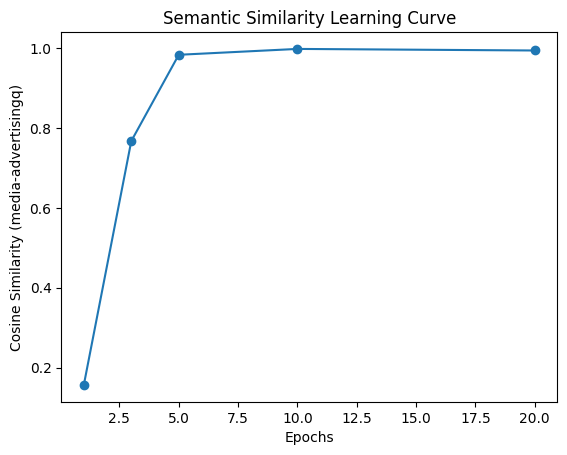

In [36]:
from gensim.models import Word2Vec
import matplotlib.pyplot as plt

sentences = df["tokens"].apply(eval).tolist()

epochs = [1, 3, 5, 10, 20]
similarities = []

for e in epochs:
    model = Word2Vec(
        sentences=sentences,
        vector_size=100,
        window=5,
        min_count=5,
        sg=1,
        epochs=e,
        workers=4
    )
    sim = model.wv.similarity("media", "advertising")
    similarities.append(sim)

plt.figure()
plt.plot(epochs, similarities, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Cosine Similarity (media-advertisingq)")
plt.title("Semantic Similarity Learning Curve")
plt.show()


In [34]:
model.wv.index_to_key[:50]


['media',
 'advertising',
 'agencies',
 'new',
 'pakistan',
 'brands',
 'agency',
 'one',
 'creative',
 'marketing',
 'buying',
 'ali',
 'clients',
 'global',
 'world',
 'time',
 'industry',
 'ai',
 'pakistans',
 'became',
 'pakistani',
 'years',
 'ad',
 'first',
 'brand',
 'consumers',
 'today',
 'edition',
 'digital',
 'business',
 'work',
 'function',
 'well',
 'change',
 'placement',
 'social',
 'good',
 'every',
 'next',
 'still',
 'best',
 'client',
 'internet',
 'communications',
 'take',
 'consumer',
 'data',
 'set',
 'design',
 'across']